In [28]:
import cv2 as cv

In [29]:
def camera( imgOrVid:str = "",runNumber:int = 0, grabFrames:bool= False, grabFrameRate:int =10):
    ''''
    Runs webcam and gets the input
    If you want a singular photo taken, set imgOrVid to "image", else it will start a video
    Please set the run number according to which run you want to store this as.
    If you want to store frames from the video, set grabFrames to true, else it will not store anything
    Set the grabFrameRate for videos, to decide at what rate to grab frames.
    '''
    ## Grabbed base code from https://stackoverflow.com/questions/2601194/displaying-a-webcam-feed-using-opencv-and-python
    vc = cv2.VideoCapture(0) # input index is 0, so first video input I assume 
    # returns a viedos capture object called vc
    if vc.isOpened(): # try to get the first frame
        rval, frame = vc.read() # returns a value (boolean I think? true) and frame
        if imgOrVid == "image" and rval != False: ## if image is the input, takes a singular photo
            cv.imwrite(f"frames/run{runNumber}snapshot.jpg", frame)
            print("took a photo")
        else: ## otherwise start a camera feed
            count = 0
            while rval:
                cv.imshow("preview", frame)
                rval, frame = vc.read() 
                # returns the retreval value and the image
                # combines grab and retrive in one call. if nothing grabbed, returns false.
                if count % grabFrameRate == 0 and grabFrames == True and rval != False: 
                ## if grabframes is true, then store frames from the camera feed at the rate specified
                    cv.imwrite(f"frames/run{runNumber}frame{count}.jpg", frame) 
                    ## this is storing all of them in the frames folder under rum#frame#.jpg
                count +=1
                key = cv.waitKey(20)
                if key == 27: # exit on ESC
                    break
    else:
        rval = False

    cv.destroyWindow("preview")
    vc.release()    

In [30]:
camera("image",1,True,10)

took a photo


(1080, 1920, 3)


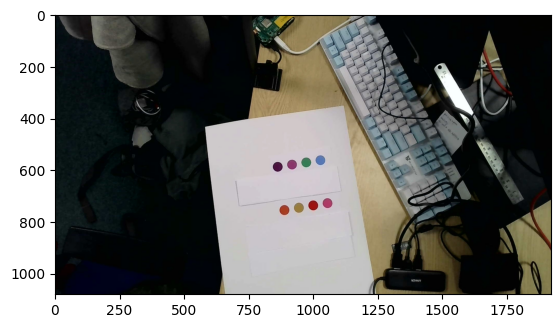

1080


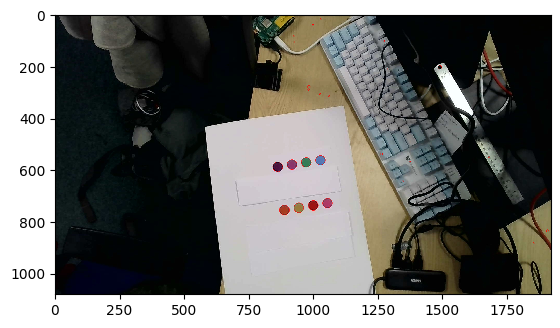

In [40]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

img_path = Path("frames/dark1s.jpg")


def find_circle_keypoints(image: np.array):
    gray = cv.cvtColor(image, cv.COLOR_RGB2GRAY)
    _, thesholded = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)
    params = cv.SimpleBlobDetector_Params()
    params.filterByCircularity = True
    params.minCircularity = 0.1
    detector = cv.SimpleBlobDetector_create(params)
    keypoints = detector.detect(thesholded)
    return keypoints


image = cv.imread(img_path, cv.IMREAD_COLOR)
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
print(image.shape)

plt.imshow(image)
plt.show()

keypoints = find_circle_keypoints(image)

blank = np.zeros((1, 1))
blobs = cv.drawKeypoints(
    image, keypoints, blank, (255, 0, 0), cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

print(len(blobs))
plt.imshow(blobs, interpolation="nearest")
plt.show()

test_dots.png


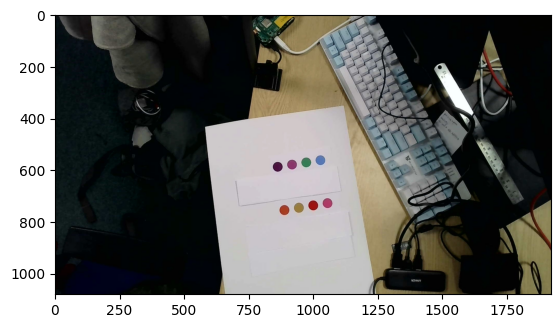

Gray Scale


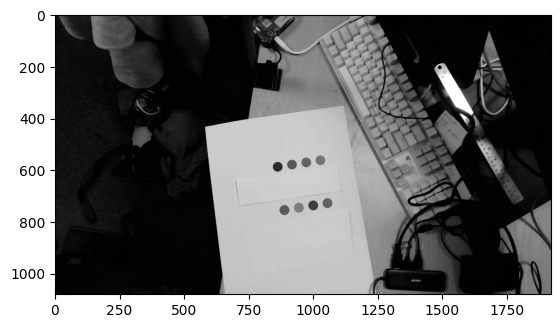

Thresholded


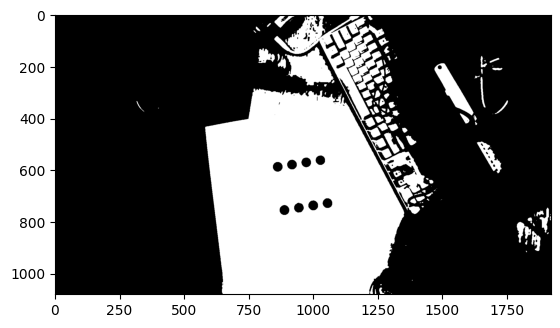

Blobs detected


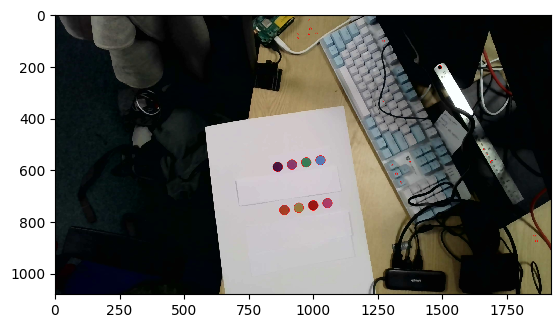

In [72]:
from pathlib import Path
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

img_path = Path("frames/dark1s.jpg")

image = cv.imread(img_path, cv.IMREAD_COLOR_RGB)
print("test_dots.png")
plt.imshow(image)
plt.show()


image = cv.medianBlur(image, 5)
gray = cv.cvtColor(image, cv.COLOR_RGBA2GRAY)
print("Gray Scale")
plt.imshow(gray, cmap="gray")
plt.show()

_, thesholded = cv.threshold(gray, 130, 255, cv.THRESH_BINARY)
print("Thresholded")
plt.imshow(thesholded, cmap="gray")
plt.show()

params = cv.SimpleBlobDetector_Params()
params.filterByCircularity = True
params.minCircularity = 0.1
detector = cv.SimpleBlobDetector_create(params)
keypoints = detector.detect(thesholded)

blank = np.zeros((1, 1))
blobs = cv.drawKeypoints(
    image, keypoints, blank, (255, 0, 0), cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

print("Blobs detected")
plt.imshow(blobs, interpolation="nearest")
plt.show()